In [2]:
# 3. CPU용 MMCV (v2.x 버전) 설치
# 현재 PyTorch 버전에 맞는 CPU 휠을 자동으로 찾아 설치합니다.
import torch
v_torch = torch.__version__.split('+')[0]
print(v_torch)


2.1.0


In [3]:
import sys
import os
import torch

# 현재 주피터 노트북 파일이 있는 위치(CVProject)를 기준으로 mmdetection 폴더 경로 지정
mmdet_path = os.path.abspath('mmdetection')
if mmdet_path not in sys.path:
    sys.path.append(mmdet_path)

import mmcv
import mmengine
import mmdet
from mmdet.apis import init_detector, inference_detector

print(f"PyTorch 버전: {torch.__version__}")
print(f"MMDetection 버전: {mmdet.__version__}")
print("✅ 준비 완료!")

C:\Users\yoonj\AppData\Roaming\Python\Python311\site-packages\imagecorruptions\corruptions.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


PyTorch 버전: 2.1.0+cpu
MMDetection 버전: 3.3.0
✅ 준비 완료!


In [4]:
### 모듈 import
from mmdet.apis import init_detector, inference_detector
import mmcv

In [6]:
!dir mmdetection\checkpoints

 Volume in drive C is Local Disk
 Volume Serial Number is DEF7-DBB3

 Directory of c:\Users\yoonj\vscodeProject\CVProject\mmdetection\checkpoints

02/04/2026  09:04 PM    <DIR>          .
02/04/2026  09:02 PM    <DIR>          ..
02/04/2026  09:10 PM       254,089,599 mask_rcnn_r101_fpn_1x_coco_20200204-1efe0ed5.pth
               1 File(s)    254,089,599 bytes
               2 Dir(s)  326,608,109,568 bytes free


### MS-COCO 데이터 기반으로 Mask RCNN Pretrained 모델을 활용하여 Inference 수행
* Mask RCNN Pretrained 모델 다운로드
* Mask RCNN용 Config 파일 설정.  
* Inference 용 모델을 생성하고, Inference 적용

In [5]:
# config 파일을 설정하고, 다운로드 받은 pretrained 모델을 checkpoint로 설정.
config_file = 'mmdetection/configs/mask_rcnn/mask-rcnn_r101_fpn_1x_coco.py'
checkpoint_file = 'mmdetection/checkpoints/mask_rcnn_r101_fpn_1x_coco_20200204-1efe0ed5.pth'

In [6]:
# config 파일과 pretrained 모델을 기반으로 Detector 모델을 생성.
from mmdet.apis import init_detector, inference_detector

model = init_detector(config_file, checkpoint_file, device='cpu')

Loads checkpoint by local backend from path: mmdetection/checkpoints/mask_rcnn_r101_fpn_1x_coco_20200204-1efe0ed5.pth


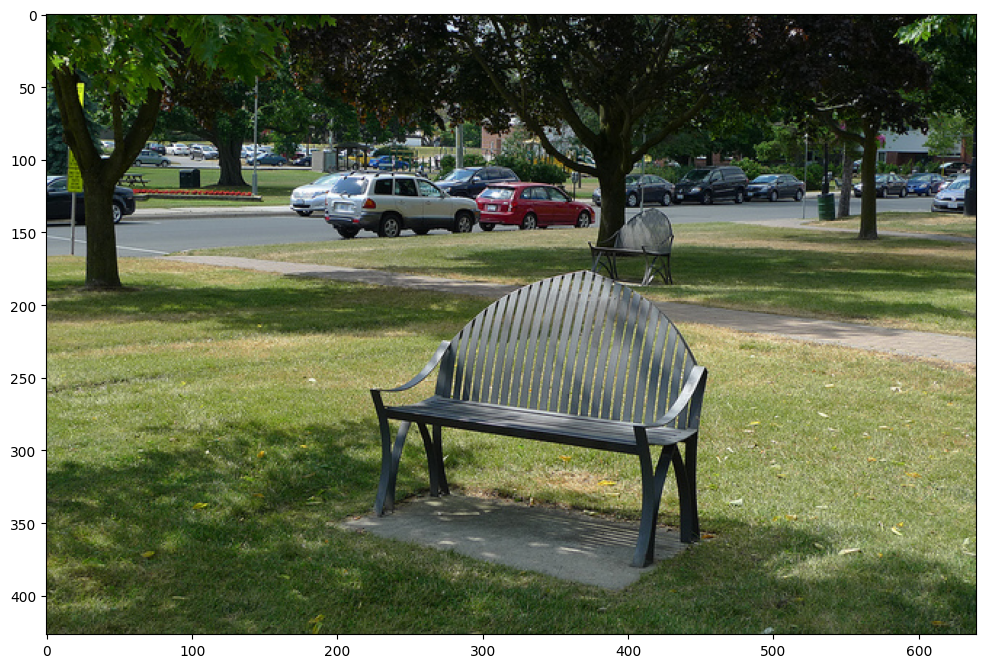

In [7]:
import cv2
import matplotlib.pyplot as plt
img = 'mmdetection/demo/demo.jpg'

img_arr  = cv2.imread(img)
img_arr_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_arr_rgb)

In [8]:
img_path = 'mmdetection/demo/demo.jpg'
# inference_detector의 인자로 string(file경로), ndarray가 단일 또는 list형태로 입력 될 수 있음.
results = inference_detector(model, img_arr)

c:\Users\yoonj\anaconda3\envs\mmdet_env\Lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


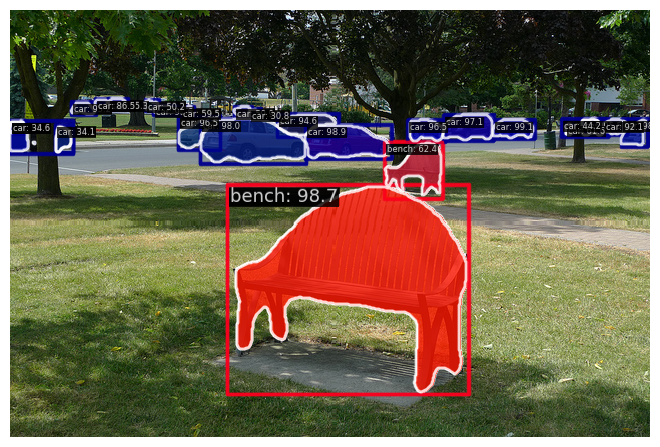

In [11]:
from mmdet.registry import VISUALIZERS
import mmcv

# 1. 이미 설정된 비주얼라이저 가져오기
visualizer = VISUALIZERS.build(model.cfg.visualizer)

# 2. 데이터셋의 메타 정보(클래스 이름 등)를 비주얼라이저에 전달
visualizer.dataset_meta = model.dataset_meta

# 3. 이미지 읽기 (img_arr가 numpy array라면 그대로 사용)
image = mmcv.imread(img_arr)
image = mmcv.imconvert(image, 'bgr', 'rgb') # 색상 보정

# 4. 결과 시각화
visualizer.add_datasample(
    'result',
    image,
    data_sample=results,
    draw_gt=False,
    wait_time=0,
    out_file=None, # 파일로 저장하고 싶으면 'result.jpg' 처럼 경로 입력
    pred_score_thr=0.3 # 0.3 이상인 것만 표시
)

# 5. 노트북에 출력
visualizer.show()

### Inference 결과로 반환되는 results 값 살펴 보기
* inference_detector(model, img_path)의 결과로 반환되는 값은 instance segmentation 일 경우 Object Detection 결과에 추가되어 segmentation masking 정보도 함께 반환됨

In [12]:
type(results)

mmdet.structures.det_data_sample.DetDataSample

In [13]:
results

<DetDataSample(

    META INFORMATION
    ori_shape: (427, 640)
    scale_factor: (1.8734375, 1.873536299765808)
    pad_shape: (800, 1216)
    img_id: 0
    img_shape: (800, 1199)
    img_path: None
    batch_input_shape: (800, 1216)

    DATA FIELDS
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], dtype=torch.int64)
            bboxes: tensor([], size=(0, 4))
            masks: BitmapMasks(num_masks=0, height=427, width=640)
        ) at 0x1d834783050>
    ignored_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], dtype=torch.int64)
            bboxes: tensor([], size=(0, 4))
            masks: BitmapMasks(num_masks=0, height=427, width=640)
        ) at 0x1d83477d050>
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([ 2,  2, 13,  2,  2,  2,

In [14]:
#현재 이미지에서 찾아낸 물체의 갯수 : 55개
print(
    type(results), len(results.pred_instances)
)

<class 'mmdet.structures.det_data_sample.DetDataSample'> 55


In [15]:
# 모델이 알고 있는 클래스 목록 확인
class_names = model.dataset_meta['classes']
print(f"클래스 목록: {class_names}")
print(f"클래스 총 개수: {len(class_names)}") 

클래스 목록: ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic_light', 'fire_hydrant', 'stop_sign', 'parking_meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports_ball', 'kite', 'baseball_bat', 'baseball_glove', 'skateboard', 'surfboard', 'tennis_racket', 'bottle', 'wine_glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot_dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed', 'dining_table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell_phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy_bear', 'hair_drier', 'toothbrush')
클래스 총 개수: 80


In [16]:
import torch

# 1. 감지된 모든 결과의 클래스 ID 가져오기
labels = results.pred_instances.labels

# 2. 0부터 79까지 각 클래스별로 개수 세기
# 리스트 컴프리헨션을 사용하여 80개 클래스 각각의 개수를 계산합니다.
num_detections_per_class = [(labels == i).sum().item() for i in range(80)]

# 결과 출력 (80개의 숫자가 담긴 리스트)
print(num_detections_per_class)

# 확인용: 0번 클래스(예: person)의 개수
print(f"Class 0 count: {num_detections_per_class[0]}")
print(f"Class 1 count: {num_detections_per_class[1]}")
print(f"Class 2 count: {num_detections_per_class[2]}")
print(f"Class 3 count: {num_detections_per_class[3]}")
print(f"Class 4 count: {num_detections_per_class[4]}")

[1, 0, 45, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Class 0 count: 1
Class 1 count: 0
Class 2 count: 45
Class 3 count: 0
Class 4 count: 0


In [17]:
import numpy as np

# 1. 초기화: 80개 클래스별로 빈 리스트 생성
mask_results = [[] for _ in range(80)]

# 2. 데이터 추출 (V3 객체에서 데이터 꺼내기)
pred_instances = results.pred_instances
masks = pred_instances.masks  # (N, H, W) 형태의 BitmapMask 혹은 Tensor
labels = pred_instances.labels.cpu().numpy()

# 3. 클래스별로 마스크 분배하기
for i in range(len(labels)):
    class_id = labels[i]
    # 마스크 데이터를 numpy array (H, W) 형태로 변환하여 저장
    mask_array = masks[i].cpu().numpy() if hasattr(masks[i], 'cpu') else masks[i]
    mask_results[class_id].append(mask_array)

# 4. 질문하신 형식의 변수명으로 매칭 (V2 스타일 재현)
# 기존 results[0]은 BBox, results[1]은 Mask였으므로 리스트로 묶어줍니다.
legacy_results = [None, mask_results]

In [18]:
# 'results[1]' 대신 가공한 'legacy_results[1]'을 사용합니다.
res_mask = legacy_results[1]

print(f'results[1]의 첫번째 원소의 type과 size: {type(res_mask[0])} {len(res_mask[0])}, '
      f'두번째 원소 사이즈: {len(res_mask[1])}, 세번째 원소 사이즈: {len(res_mask[2])}')

# 각 클래스에 물체가 하나 이상 검출되었는지 확인 후 출력 (IndexError 방지)
if len(res_mask[0]) > 0:
    print(f'results[1]의 첫번째 원소 list의 첫번째 원소 type과 shape: {type(res_mask[0][0])} {res_mask[0][0].shape}')

if len(res_mask[2]) >= 3:
    print(f'results[1]의 세번째 원소 list의 첫번째/두번째/세번째 원소 shape: '
          f'{res_mask[2][0].shape}, {res_mask[2][1].shape}, {res_mask[2][2].shape}')

print('image shape:', img_arr.shape)

results[1]의 첫번째 원소의 type과 size: <class 'list'> 1, 두번째 원소 사이즈: 0, 세번째 원소 사이즈: 45
results[1]의 첫번째 원소 list의 첫번째 원소 type과 shape: <class 'numpy.ndarray'> (427, 640)
results[1]의 세번째 원소 list의 첫번째/두번째/세번째 원소 shape: (427, 640), (427, 640), (427, 640)
image shape: (427, 640, 3)


In [19]:
# 1. 0번 클래스의 첫 번째 객체 마스크 가져오기
# (IndexError 방지를 위해 데이터가 있는지 먼저 확인하는 것이 좋습니다)
if len(res_mask[0]) > 0:
    mask_imsi = res_mask[0][0]
    
    print("--- mask_imsi 정보 ---")
    print(mask_imsi) # 전체 배열 출력 (주로 0과 1 또는 True/False)
    
    # 2. 마스크 내부의 값 필터링 출력
    # mask_imsi가 True/False 형태라면 > 0 대신 == True 를 사용해도 됩니다.
    pos_values = mask_imsi[mask_imsi > 0]
    neg_values = mask_imsi[mask_imsi == 0]
    
    print(f"Positive values (Mask 영역): {pos_values}")
    print(f"Zero values (배경 영역): {neg_values}")
    print(f"Mask 된 픽셀 수: {len(pos_values)}")
else:
    print("0번 클래스에 검출된 물체가 없습니다.")

--- mask_imsi 정보 ---
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
Positive values (Mask 영역): [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]
Zero values (배경 영역): [False False False ... False False False]
Mask 된 픽셀 수: 72


(-0.5, 639.5, 426.5, -0.5)

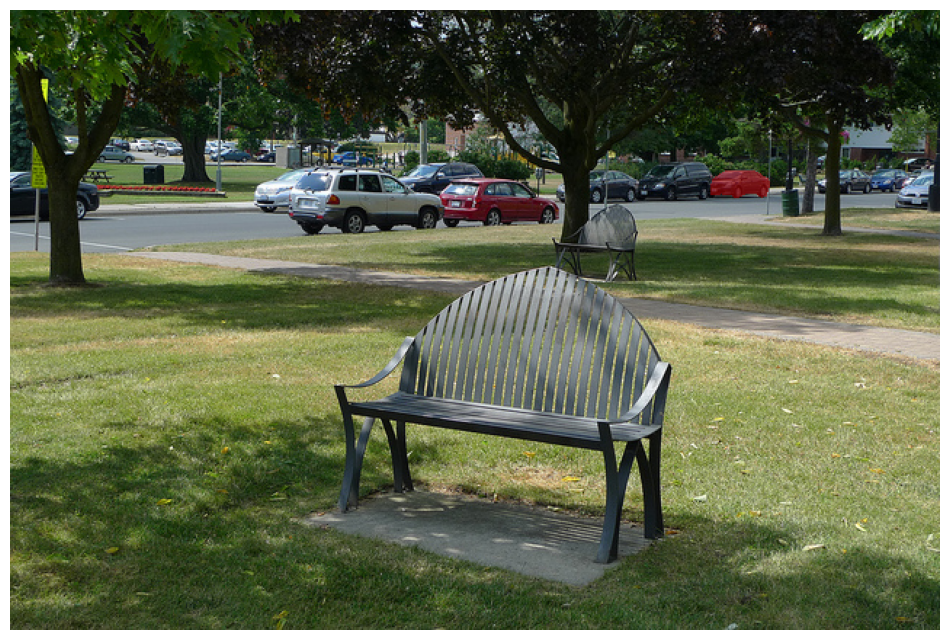

In [20]:
import numpy as np
# 2번 클래스(COCO 기준 car)의 0번째 인스턴스 마스크를 가져옵니다.
# 주의: res_mask는 위에서 만든 legacy_results[1] (80개 리스트)여야 합니다.
target_class_id = 2
target_instance_id = 0
mask_to_apply = res_mask[target_class_id][target_instance_id]

def apply_mask(image, mask,color,alpha=0.5):
    for c in range(3):
        #mask 값이 1일 경우는 원본 pixel 값에 컬러 segmentation을 적용하고, 그렇지 않을 경우 원본 pixel 값을 그대로 유지
        image[:,:,c] = np.where(mask==1,
                                image[:,:,c]*
                                (1-alpha)+alpha*color[c]*255,
                                image[:,:,c])
    return image

draw_img = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
masked_image = apply_mask(draw_img, mask_to_apply, (255,0,0), alpha=0.6) # 빨간색으로 마스킹
plt.figure(figsize=(12,14))
plt.imshow(masked_image)
plt.axis('off')

### Video Detection 실행
* mmdetection의 model.show_result()를 실행하여 frame별로 object detect 된 결과를 시각화

In [ ]:
#사용할 동영상 다운로드
#!curl -L -o dataset/John_Wick_small.mp4 https://github.com/chulminkw/DLCV/blob/master/data/video/John_Wick_small.mp4?raw=true

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:04 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:06 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:07 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:08 --:--:--     0
  0     0    0     0    0     0      0      0 --:--

In [44]:
from mmdet.apis import inference_detector
from mmdet.visualization import DetLocalVisualizer
from mmengine.utils import track_iter_progress
import cv2
import numpy as np

# 1. Visualizer 직접 설정
# 모델의 메타데이터(클래스 이름 등)를 visualizer에 주입합니다.
visualizer = DetLocalVisualizer.get_instance(
    name='my_visualizer',
    vis_backends=[dict(type='LocalVisBackend')],
    save_dir='temp_vis'
)
visualizer.dataset_meta = model.dataset_meta

# 2. 영상 쓰기 설정
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter('dataset/John_Wick_small_out1.mp4', fourcc, 
                                video_reader.fps, (video_reader.width, video_reader.height))

# 3. Frame 별로 inference 진행
for frame in track_iter_progress(list(video_reader)):
    # inference_detector는 BGR 이미지를 입력받습니다.
    result = inference_detector(model, frame)
    
    # 시각화를 위해 RGB로 변환
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 시각화 데이터 추가
    visualizer.add_datasample(
        name='video_frame',
        image=img_rgb,
        data_sample=result,
        draw_gt=False,
        show=False,
        pred_score_thr=0.4
    )
    
    # 그려진 이미지 추출 (RGB -> BGR 변환 후 저장)
    frame_vis = visualizer.get_image()
    frame_vis = cv2.cvtColor(frame_vis, cv2.COLOR_RGB2BGR)
    
    video_writer.write(frame_vis)

# 4. 자원 해제
video_writer.release()
print("\n비디오 저장 완료!")

c:\Users\yoonj\anaconda3\envs\mmdet_env\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of my_visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


[>>                               ] 4/58, 0.2 task/s, elapsed: 22s, ETA:   303s

c:\Users\yoonj\anaconda3\envs\mmdet_env\Lib\site-packages\mmengine\visualization\visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
c:\Users\yoonj\anaconda3\envs\mmdet_env\Lib\site-packages\mmengine\visualization\visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(


[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 58/58, 0.2 task/s, elapsed: 353s, ETA:     0s

비디오 저장 완료!


### segmentation 시각화 함수 직접 작성 후 단일 이미지와 Video inference 수행.

In [1]:
# 0부터 순차적으로 클래스 매핑된 label 적용.
labels_to_names_seq = {0:'person',1:'bicycle',2:'car',3:'motorbike',4:'aeroplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',10:'fire hydrant',
                        11:'stop sign',12:'parking meter',13:'bench',14:'bird',15:'cat',16:'dog',17:'horse',18:'sheep',19:'cow',20:'elephant',
                        21:'bear',22:'zebra',23:'giraffe',24:'backpack',25:'umbrella',26:'handbag',27:'tie',28:'suitcase',29:'frisbee',30:'skis',
                        31:'snowboard',32:'sports ball',33:'kite',34:'baseball bat',35:'baseball glove',36:'skateboard',37:'surfboard',38:'tennis racket',39:'bottle',40:'wine glass',
                        41:'cup',42:'fork',43:'knife',44:'spoon',45:'bowl',46:'banana',47:'apple',48:'sandwich',49:'orange',50:'broccoli',
                        51:'carrot',52:'hot dog',53:'pizza',54:'donut',55:'cake',56:'chair',57:'sofa',58:'pottedplant',59:'bed',60:'diningtable',
                        61:'toilet',62:'tvmonitor',63:'laptop',64:'mouse',65:'remote',66:'keyboard',67:'cell phone',68:'microwave',69:'oven',70:'toaster',
                        71:'sink',72:'refrigerator',73:'book',74:'clock',75:'vase',76:'scissors',77:'teddy bear',78:'hair drier',79:'toothbrush' }

colors = list(
    [[0, 255, 0],
     [0, 0, 255],
     [255, 0, 0],
     [0, 255, 255],
     [255, 255, 0],
     [255, 0, 255],
     [80, 70, 180],
     [250, 80, 190],
     [245, 145, 50],
     [70, 150, 250]] )

In [9]:
#mask threshold값은 mask_thr_binary=0.5 로 지정되어 있음.
print(model.cfg.pretty_text)

auto_scale_lr = dict(base_batch_size=16, enable=False)
backend_args = None
data_root = 'data/coco/'
dataset_type = 'CocoDataset'
default_hooks = dict(
    checkpoint=dict(interval=1, type='CheckpointHook'),
    logger=dict(interval=50, type='LoggerHook'),
    param_scheduler=dict(type='ParamSchedulerHook'),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    timer=dict(type='IterTimerHook'),
    visualization=dict(type='DetVisualizationHook'))
default_scope = 'mmdet'
env_cfg = dict(
    cudnn_benchmark=False,
    dist_cfg=dict(backend='nccl'),
    mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0))
load_from = None
log_level = 'INFO'
log_processor = dict(by_epoch=True, type='LogProcessor', window_size=50)
model = dict(
    backbone=dict(
        depth=101,
        frozen_stages=1,
        init_cfg=None,
        norm_cfg=dict(requires_grad=True, type='BN'),
        norm_eval=True,
        num_stages=4,
        out_indices=(
            0,
            1,
            2,
        

In [ ]:
import numpy as np
import cv2

def get_detected_img(model, img_array, score_threshold=0.3, is_print=True):
    draw_img = img_array.copy()
    bbox_color = (0, 255, 0) #박스색깔 초록색 (BGR 순서)
    text_color = (0, 0, 255) #텍스트 색깔 빨간색 (BGR순서)
    all_masks = []  # 검출된 마스크들을 저장할 리스트

    # 1. Inference 수행
    result = inference_detector(model, img_array)
    
    # MMDet 3.x 에서는 result.pred_instances에 데이터가 담겨 있습니다.
    pred_instances = result.pred_instances
    
    # score_threshold 보다 높은 것들만 필터링한 인덱스 추출
    scores = pred_instances.scores.cpu().numpy()
    valid_inds = np.where(scores > score_threshold)[0]
    
    # 필터링된 데이터들
    bboxes = pred_instances.bboxes.cpu().numpy()[valid_inds]
    labels = pred_instances.labels.cpu().numpy()[valid_inds]
    masks = pred_instances.masks.cpu().numpy()[valid_inds] if 'masks' in pred_instances else None
    scores = scores[valid_inds]

    for i in range(len(bboxes)):
        current_mask = masks[i]
        all_masks.append(current_mask)

        left, top, right, bottom = bboxes[i].astype(int)
        score = scores[i]
        label_name = labels_to_names_seq[labels[i]]
        caption = f"{label_name}: {score:.4f}"

        # Bbox 및 Text 그리기
        cv2.rectangle(draw_img, (left, top), (right, bottom), color=bbox_color, thickness=2)
        cv2.putText(draw_img, caption, (left, top - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.37, text_color, 1)

        # Mask 시각화 (데이터 타입 및 연산 수정)
        if masks is not None:
            class_mask_array = masks[i]  # 이 배열은 (H, W) 형태의 boolean
            
            # 색상 선택
            color_index = np.random.randint(0, len(colors) - 1)
            color = np.array(colors[color_index], dtype=np.float32)

            # Mask가 True인 영역에 대해서만 블렌딩 처리 (np.where 사용 권장)
            # draw_img를 float32로 변환하여 계산 후 다시 uint8로 변환
            mask_indices = np.where(class_mask_array)
            
            # 원본 영역의 픽셀값
            roi = draw_img[mask_indices].astype(np.float32)
            # 투명도 적용 계산 (0.4 * color + 0.6 * original)
            blended = (0.4 * color + 0.6 * roi).astype(np.uint8)
            
            draw_img[mask_indices] = blended

        if is_print:
            print(caption)

    return draw_img, all_masks

In [32]:
img_arr = cv2.imread('mmdetection/demo/demo.jpg')
detected_img, mask_list = get_detected_img(model, img_arr)

# 특정 마스크 확인 (예: 첫 번째 검출된 객체의 마스크)
if len(mask_list) > 0:
    first_mask = mask_list[0] 
    print(f"Mask Shape: {first_mask.shape}") # (H, W) 형태


car: 0.9910
car: 0.9892
bench: 0.9872
car: 0.9833
car: 0.9832
car: 0.9801
car: 0.9715
car: 0.9654
car: 0.9650
car: 0.9546
car: 0.9531
car: 0.9524
car: 0.9464
car: 0.9209
car: 0.9160
car: 0.8646
bench: 0.6239
car: 0.6161
car: 0.5985
car: 0.5947
car: 0.5020
car: 0.4424
car: 0.3456
car: 0.3411
car: 0.3080
Mask Shape: (427, 640)


car: 0.9910
car: 0.9892
bench: 0.9872
car: 0.9833
car: 0.9832
car: 0.9801
car: 0.9715
car: 0.9654
car: 0.9650
car: 0.9546
car: 0.9531
car: 0.9524
car: 0.9464
car: 0.9209
car: 0.9160
car: 0.8646
bench: 0.6239
car: 0.6161
car: 0.5985
car: 0.5947
car: 0.5020
car: 0.4424
car: 0.3456
car: 0.3411
car: 0.3080


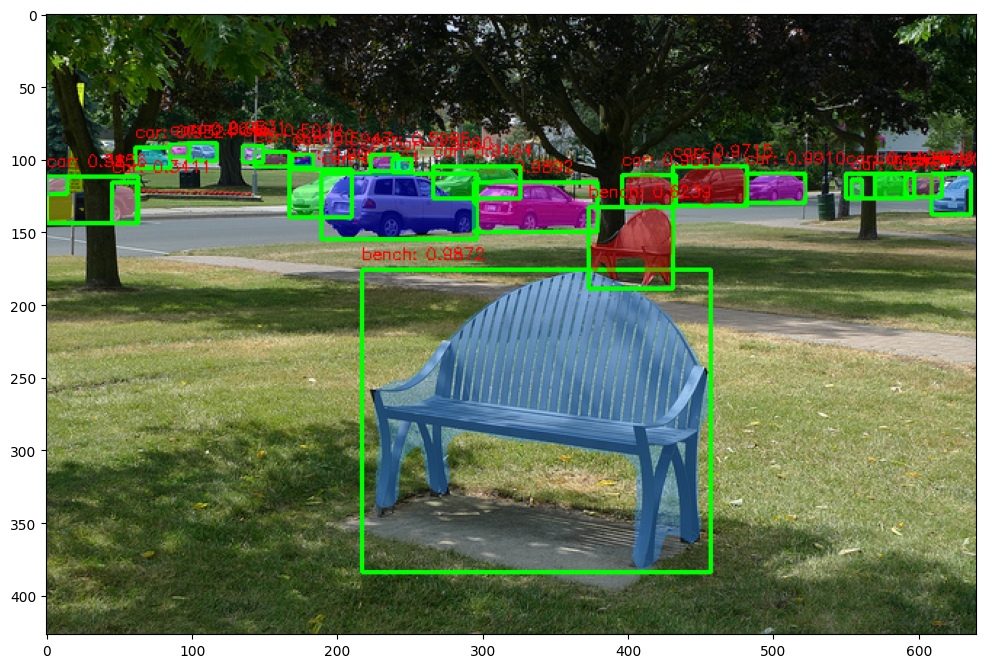

In [34]:
import matplotlib.pyplot as plt

img_arr = cv2.imread('mmdetection/demo/demo.jpg')
detected_img , mask_list = get_detected_img(model, img_arr,  score_threshold=0.3, is_print=True)
# detect 입력된 이미지는 bgr임. 이를 최종 출력시 rgb로 변환
detected_img = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(detected_img)
plt.show()

In [ ]:
#beatles01.jpg 파일 다운로드
#!curl -L -o  ./dataset/beatles01.jpg https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/beatles01.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  374k  100  374k    0     0   794k      0 --:--:-- --:--:-- --:--:--  801k


person: 0.9992
person: 0.9991
person: 0.9980
person: 0.9974
car: 0.9596
car: 0.9578
car: 0.9487
person: 0.9378
car: 0.9288
car: 0.9221
car: 0.8884
car: 0.8715
car: 0.8034
car: 0.7781
tie: 0.5624
car: 0.4521
truck: 0.3594
car: 0.3580
tie: 0.3392
truck: 0.3297
car: 0.3103


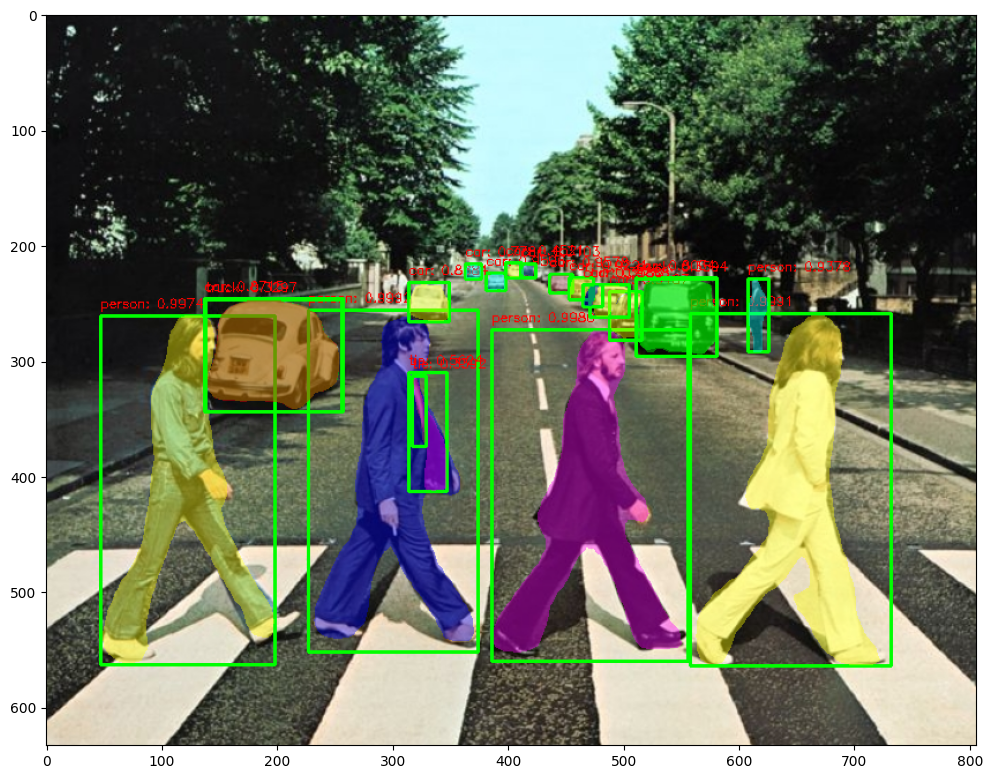

In [38]:
import matplotlib.pyplot as plt

img_arr = cv2.imread('dataset/beatles01.jpg')
detected_img, mask_list = get_detected_img(model, img_arr,  score_threshold=0.3, is_print=True)
# detect 입력된 이미지는 bgr임. 이를 최종 출력시 rgb로 변환
detected_img = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(detected_img)
plt.show()

In [41]:
import time

def do_detected_video(model, input_path, output_path, score_threshold, do_print=True):

    cap = cv2.VideoCapture(input_path)

    codec = cv2.VideoWriter_fourcc(*'XVID')

    vid_size = (round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    vid_fps = cap.get(cv2.CAP_PROP_FPS)

    vid_writer = cv2.VideoWriter(output_path, codec, vid_fps, vid_size)

    frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print('총 Frame 갯수:', frame_cnt)
    btime = time.time()
    while True:
        hasFrame, img_frame = cap.read()
        if not hasFrame:
            print('더 이상 처리할 frame이 없습니다.')
            break
        stime = time.time()
        img_frame , mask_list= get_detected_img(model, img_frame,  score_threshold=score_threshold,is_print=False)
        if do_print:
          print('frame별 detection 수행 시간:', round(time.time() - stime, 4))
        vid_writer.write(img_frame)
    # end of while loop

    vid_writer.release()
    cap.release()

    print('최종 detection 완료 수행 시간:', round(time.time() - btime, 4))

In [42]:
do_detected_video(model, 'dataset/John_Wick_small.mp4', 'dataset/John_Wick_small_out2.mp4', score_threshold=0.4, do_print=True)

총 Frame 갯수: 58
frame별 detection 수행 시간: 4.7852
frame별 detection 수행 시간: 7.6304
frame별 detection 수행 시간: 11.3833
frame별 detection 수행 시간: 11.2636
frame별 detection 수행 시간: 11.1444
frame별 detection 수행 시간: 11.4244
frame별 detection 수행 시간: 11.0905
frame별 detection 수행 시간: 7.5488
frame별 detection 수행 시간: 9.7092
frame별 detection 수행 시간: 5.9008
frame별 detection 수행 시간: 9.8358
frame별 detection 수행 시간: 10.4659
frame별 detection 수행 시간: 8.9219
frame별 detection 수행 시간: 11.2725
frame별 detection 수행 시간: 10.7878
frame별 detection 수행 시간: 10.7463
frame별 detection 수행 시간: 10.1861
frame별 detection 수행 시간: 4.6636
frame별 detection 수행 시간: 4.9976
frame별 detection 수행 시간: 4.8667
frame별 detection 수행 시간: 4.796
frame별 detection 수행 시간: 4.8479
frame별 detection 수행 시간: 4.6906
frame별 detection 수행 시간: 4.9006
frame별 detection 수행 시간: 4.8878
frame별 detection 수행 시간: 5.0152
frame별 detection 수행 시간: 4.6391
frame별 detection 수행 시간: 4.8223
frame별 detection 수행 시간: 4.7826
frame별 detection 수행 시간: 4.8746
frame별 detection 수행 시간: 4.9614
frame별 detectio